# 02 Dataset Cleaning and Preprocessing

This notebook profiles, assesses, cleans, validates, and exports the merged webcam-based PM2.5 dataset.

Input: `data/interim/merged_dataset.csv`

Output: `data/processed/final_dataset.csv`

## Workflow Overview
1. Data loading  
2. Data profiling  
3. Data quality assessment  
4. Data cleaning  
5. Validation and visualization  
6. Export and summary

## Setup

In [74]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mno

plt.style.use("default")
sns.set_theme(style="whitegrid")

## 1. Data Loading

Load the merged dataset generated from the previous dataset construction pipeline.


In [75]:
PROJECT_ROOT = Path.cwd().parent

INPUT_FILE = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "merged_dataset.csv"
)

# Load merged dataset
df_raw = pd.read_csv(INPUT_FILE)

print("Input:", INPUT_FILE.relative_to(PROJECT_ROOT))

print(f"Rows: {len(df_raw)}")
print(f"Columns: {df_raw.shape[1]}")


Input: data/interim/merged_dataset.csv
Rows: 2708
Columns: 33


In [76]:
# Create working copy
df = df_raw.copy()

## 2. Data Profiling

Inspect dataset structure, temporal coverage, data types, and basic numerical summaries.

### 2.1 Basic structure

In [77]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2708 entries, 0 to 2707
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   time                    2708 non-null   object 
 1   R_roi                   2708 non-null   float64
 2   G_roi                   2708 non-null   float64
 3   B_roi                   2708 non-null   float64
 4   S_mean                  2708 non-null   float64
 5   B_R_ratio               2708 non-null   float64
 6   contrast                2708 non-null   float64
 7   image_path              2708 non-null   object 
 8   PM25                    2708 non-null   float64
 9   Unit                    2708 non-null   object 
 10  T2M                     2708 non-null   float64
 11  D2M                     2708 non-null   float64
 12  RH                      2708 non-null   float64
 13  U10                     2708 non-null   float64
 14  V10                     2708 non-null   

,time,R_roi,G_roi,B_roi,S_mean,B_R_ratio,contrast,image_path,PM25,Unit,...,T_500,T_850,U_500,U_850,V_500,V_850,temperature_mean,wind_direction_mean,relative_humidity_mean,wind_speed_mean
0,2026-03-03 03:00:00,84.341967,98.325697,119.317695,0.299790,1.414689,24.782218,data/raw/images/20260303-0400.jpg,36.887860,ug.m-3,...,248.84480,274.42140,12.307693,1.781799,-3.885681,1.179291,10.5,346.0,89.8,NaN
1,2026-03-03 04:00:00,84.496745,100.437798,121.108656,0.308178,1.433294,24.743914,data/raw/images/20260303-0500.jpg,41.105724,ug.m-3,...,248.77457,274.36066,11.759583,1.841400,-4.528091,0.527161,10.1,329.0,92.8,NaN
2,2026-03-03 05:00:00,86.156668,102.558431,123.832534,0.310254,1.437295,25.390314,data/raw/images/20260303-0600.jpg,39.344910,ug.m-3,...,248.74742,274.40660,11.549728,1.765808,-4.992783,-0.205154,9.5,317.0,95.9,0.5
3,2026-03-03 06:00:00,107.791262,140.798753,171.635324,0.376464,1.592293,29.475461,data/raw/images/20260303-0700.jpg,39.375263,ug.m-3,...,248.74470,274.49945,11.213989,1.240723,-5.396957,-0.769363,9.5,354.0,95.1,0.5
4,2026-03-03 07:00:00,117.449382,145.046152,168.683505,0.312937,1.436223,31.377434,data/raw/images/20260303-0800.jpg,38.800594,ug.m-3,...,248.74140,274.53918,10.838104,0.719833,-5.423553,-0.914719,9.3,328.0,94.7,NaN


### 2.2 Missing-value overview

Analyze missing values across all variables to identify incomplete observations and potential data quality issues.

In [78]:
missing_summary = (
    pd.DataFrame({
        "missing_count": df_raw.isna().sum(),
        "missing_percent": df_raw.isna().mean() * 100,
    })
    .sort_values("missing_percent", ascending=False)
)

missing_summary.head(15)

,missing_count,missing_percent
CBH,700,25.849335
wind_speed_mean,210,7.754801
wind_direction_mean,10,0.369276
temperature_mean,1,0.036928
BLH,0,0.000000
relative_humidity_mean,0,0.000000
V_850,0,0.000000
V_500,0,0.000000
U_850,0,0.000000
U_500,0,0.000000


<Figure size 1000x500 with 0 Axes>

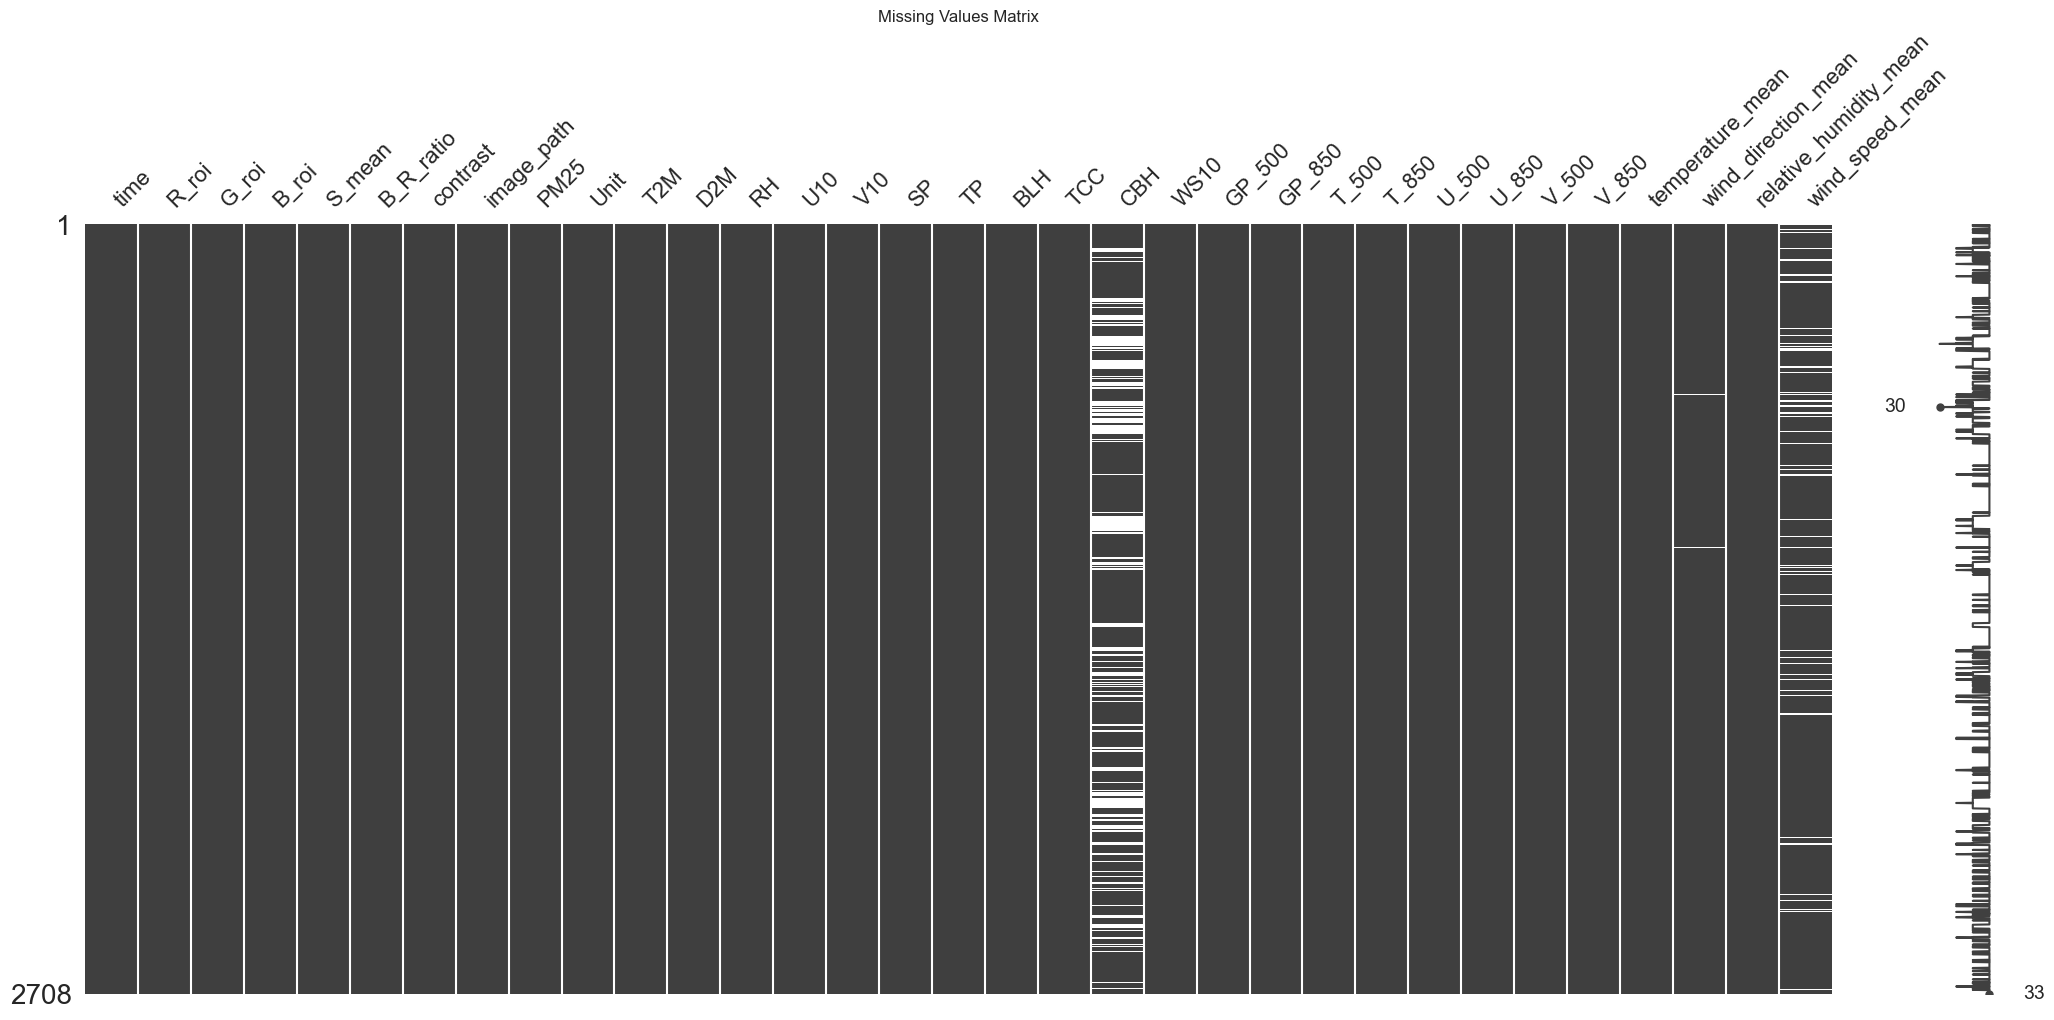

In [79]:
plt.figure(figsize=(10, 5))

mno.matrix(df)

plt.title("Missing Values Matrix")

plt.show()

### 2.3 Temporal coverage
Inspect temporal consistency, timestamp uniqueness, and continuity of the hourly observations.

In [80]:
# Time range
df["time"] = pd.to_datetime(df["time"])

print("Start time:", df["time"].min())
print("End time:", df["time"].max())

print(
    "Unique timestamps:",
    df["time"].nunique()
)

Start time: 2026-03-03 03:00:00
End time: 2026-07-17 11:00:00
Unique timestamps: 2708


In [81]:
#Duplicate timestamps
duplicate_count = df["time"].duplicated().sum()

print("Duplicated timestamps:", duplicate_count)


Duplicated timestamps: 0


In [82]:
#Hourly continuity
expected_range = pd.date_range(
    start=df["time"].min(),
    end=df["time"].max(),
    freq="h"
)

missing_times = expected_range.difference(df["time"])

print("Expected timestamps:", len(expected_range))
print("Observed timestamps:", len(df["time"]))
print("Missing timestamps:", len(missing_times))

Expected timestamps: 3273
Observed timestamps: 2708
Missing timestamps: 565


### 2.4 Numerical profiling

Explore numerical variables through descriptive statistics, distributions, and correlation analysis.

In [83]:
# Descriptive statistics
numeric_summary = (
    df.select_dtypes(include="number")
    .describe()
    .T
)

numeric_summary

,count,mean,std,min,25%,50%,75%,max
R_roi,2708.0,102.633819,19.710786,54.223291,86.860588,107.794139,117.558730,147.479453
G_roi,2708.0,128.503096,22.678224,73.304333,110.381294,135.780629,145.153808,178.284016
B_roi,2708.0,153.843220,23.285861,98.174977,134.874751,160.671714,171.504425,204.298585
S_mean,2708.0,0.360762,0.046557,0.000000,0.331971,0.352255,0.382535,0.550704
B_R_ratio,2708.0,1.515278,0.115693,1.000000,1.444513,1.494046,1.564129,2.190082
contrast,2708.0,45.060699,9.796679,0.000000,35.295097,47.358540,52.276215,76.900529
PM25,2708.0,-456.171217,2117.243186,-9999.000000,6.065560,9.816711,15.722218,75.183060
T2M,2708.0,293.461487,7.817243,276.952200,287.142507,292.942155,299.291025,310.883480
D2M,2708.0,283.371458,6.166580,261.327300,279.484722,283.824250,288.034755,296.177860
RH,2708.0,56.017036,19.204594,16.088412,40.735128,54.633748,70.766333,97.087242


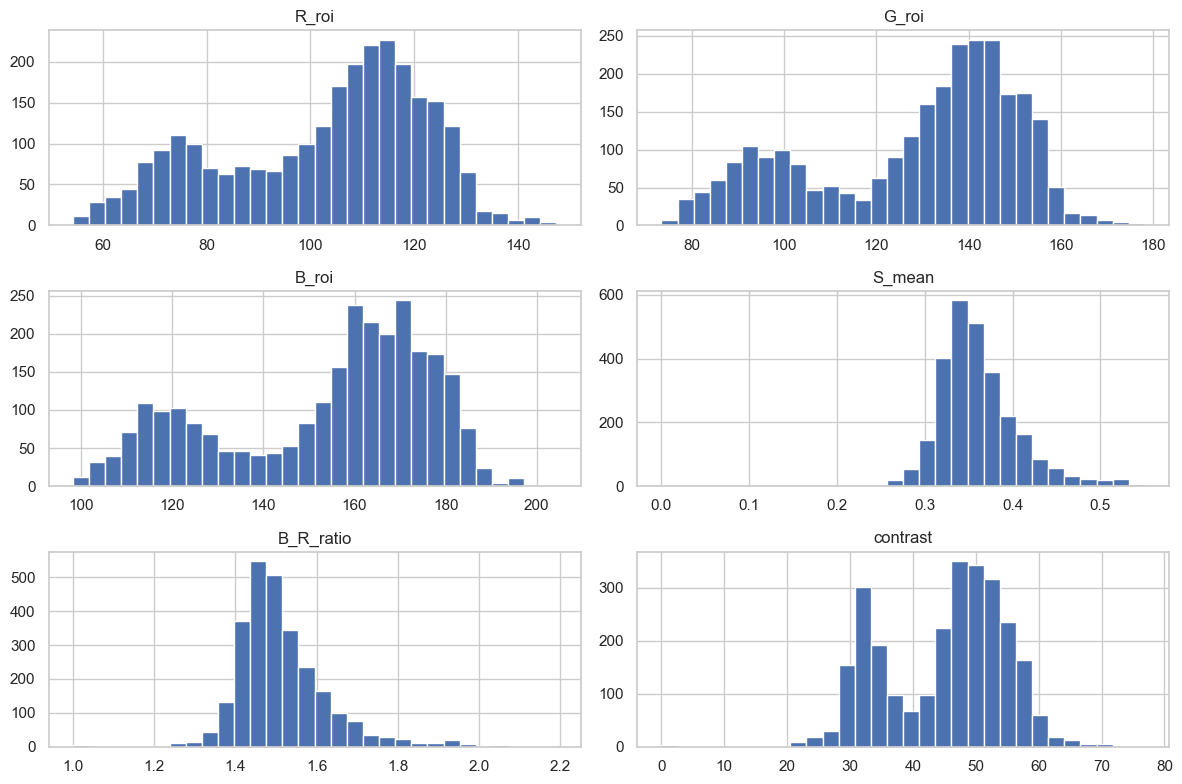

In [84]:
#  Numerical distributions-image features
image_vars = [
    "R_roi",
    "G_roi",
    "B_roi",
    "S_mean",
    "B_R_ratio",
    "contrast",
]

df[image_vars].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()

plt.show()

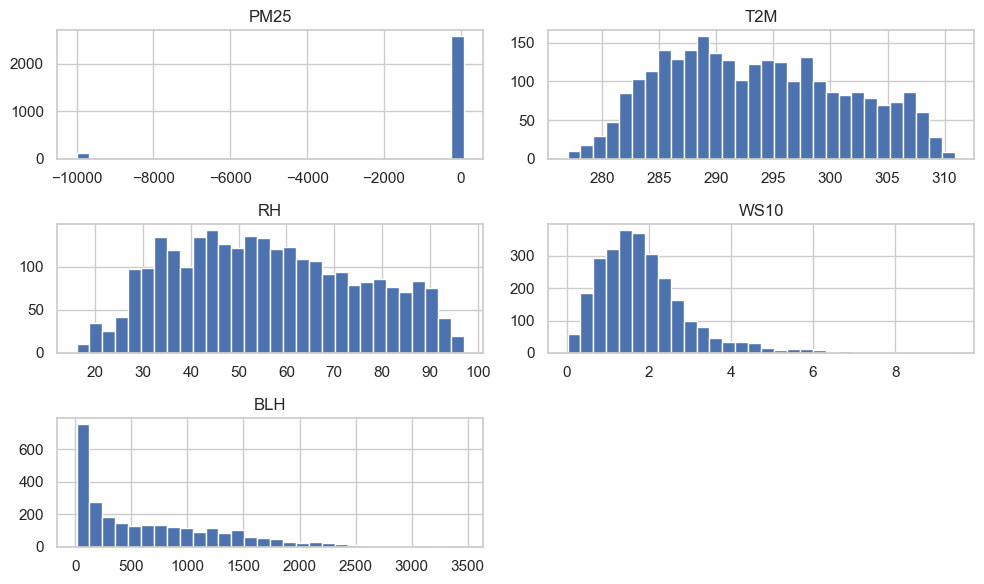

In [85]:
# Numerical distributions-target + weather variables
weather_vars = [
    "PM25",
    "T2M",
    "RH",
    "WS10",
    "BLH",
]

df[weather_vars].hist(
    figsize=(10, 6),
    bins=30
)

plt.tight_layout()

plt.show()

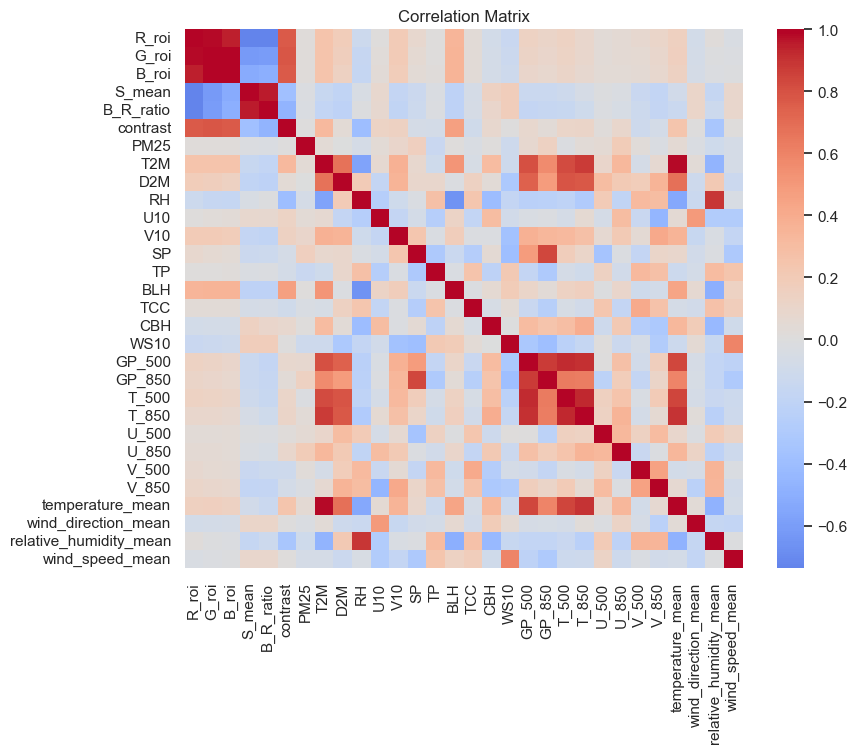

In [86]:
# Correlation analysis
corr_matrix = (
    df.select_dtypes(include="number")
    .corr()
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

## 3. Data Quality Assessment

Assess missing values, invalid physical values, duplicates, and potential outliers before applying cleaning rules.

### 3.1 Missing-value assessment

In [87]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0]

missing_summary.sort_values(by="missing_percent", ascending=False)

,missing_count,missing_percent
CBH,700,25.85
wind_speed_mean,210,7.75
wind_direction_mean,10,0.37
temperature_mean,1,0.04


### 3.2 Duplicate assessment


In [88]:
print("Duplicated rows:", df_raw.duplicated().sum())
print("Duplicated timestamps:", df_raw["time"].duplicated().sum())

Duplicated rows: 0
Duplicated timestamps: 0


### 3.3 Invalid-value assessment

In [89]:
checks = {}

# PM2.5
checks["PM25_negative"] = (df["PM25"] < 0).sum()

# Relative humidity
checks["ERA5_RH_outside_0_100"] = (
    (df["RH"] < 0) |(df["RH"] > 100)).sum()

checks["ARPA_RH_outside_0_100"] = (
    (df["relative_humidity_mean"] < 0) |(df["relative_humidity_mean"] > 100)).sum()

# Total cloud cover
checks["TCC_outside_0_1"] = (
    (df["TCC"] < 0) |(df["TCC"] > 1)).sum()

# Precipitation
checks["TP_negative"] = (df["TP"] < 0).sum()

# Wind speed
checks["wind_speed_mean_negative"] = (df["wind_speed_mean"] < 0).sum()

checks["WS10_negative"] = (df["WS10"] < 0).sum()

# Convert to dataframe
invalid_summary = pd.DataFrame.from_dict(
    checks,orient="index",columns=["count"])

invalid_summary

,count
PM25_negative,127
ERA5_RH_outside_0_100,0
ARPA_RH_outside_0_100,0
TCC_outside_0_1,0
TP_negative,0
wind_speed_mean_negative,0
WS10_negative,0


### 3.4 Outlier assessment

In [90]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

outlier_rows = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = int(
        ((df[col] < lower) | (df[col] > upper)).sum()
    )

    outlier_rows.append({
        "column": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "iqr_outlier_count": count,
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values(
    "iqr_outlier_count",
    ascending=False
)

outlier_summary.head(15)

,column,lower_bound,upper_bound,iqr_outlier_count
13,TP,-0.000009,0.000014,572
6,PM25,-8.419428,30.207206,346
25,V_850,-6.153923,6.652992,189
16,CBH,-2280.237800,6772.098000,167
4,B_R_ratio,1.265088,1.743554,133
23,U_850,-6.046305,6.276556,131
17,WS10,-0.788964,4.260982,124
11,V10,-3.018503,3.266150,122
24,V_500,-19.772213,12.539890,122
3,S_mean,0.256124,0.458382,110


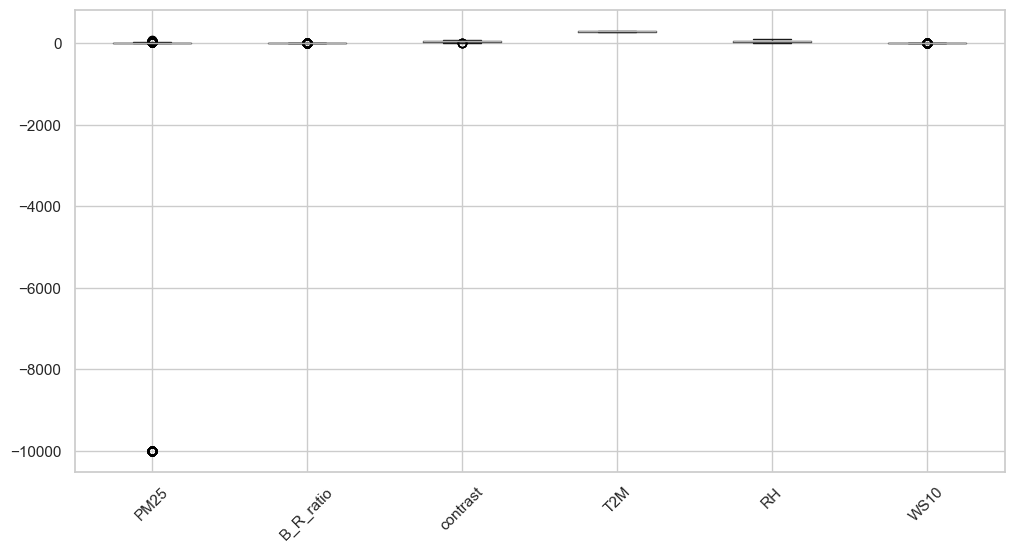

In [91]:
selected_vars = [
    "PM25",
    "B_R_ratio",
    "contrast",
    "T2M",
    "RH",
    "WS10",
]

plt.figure(figsize=(12, 6))

df[selected_vars].boxplot()

plt.xticks(rotation=45)

plt.show()

### 3.5 Temporal consistency assessment

In [92]:
expected_range = pd.date_range(
    start=df["time"].min(),
    end=df["time"].max(),
    freq="h"
)

missing_times = expected_range.difference(df["time"])

print(
    "Missing timestamps:",
    len(missing_times)
)

Missing timestamps: 565


## 4. Data Cleaning

Apply data type conversion, missing-value handling, invalid-value correction, deduplication, and feature transformation.

### 4.1 Data Transformation and Standardization

Standardize the dataset structure by converting time fields and sorting observations chronologically.

In [93]:
df["time"] = pd.to_datetime(df["time"],errors="coerce")

print( "Invalid time values:",df["time"].isna().sum())

df = df.sort_values("time").reset_index(drop=True)

print("Time range:",df["time"].min(),"to",df["time"].max())

print( "Rows:",len(df))

Invalid time values: 0
Time range: 2026-03-03 03:00:00 to 2026-07-17 11:00:00
Rows: 2708


### 4.2 Missing-Value Handling

Handle missing values using variable-specific interpolation and filling strategies.

In [94]:
missing_before = df.isna().sum().sum()

# Linear interpolation for continuous hourly variables
continuous_columns = [
    "temperature_mean",
    "relative_humidity_mean",
    "wind_speed_mean",
    "CBH",
]

for col in continuous_columns:
    if col in df.columns and df[col].isna().any():
        df[col] = df[col].interpolate(
            method="linear",
            limit_direction="both"
        )

# Wind direction is circular data
if "wind_direction_mean" in df.columns:
    df["wind_direction_mean"] = (
        df["wind_direction_mean"]
        .ffill()
        .bfill()
    )

missing_after = df.isna().sum().sum()

print("Missing values before:", missing_before)
print("Missing values after:", missing_after)

Missing values before: 921
Missing values after: 0


In [95]:
missing_after_summary = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean() * 100).round(2).values
})

missing_after_summary = missing_after_summary[
    missing_after_summary["missing_count"] > 0
].sort_values(
    by="missing_percent",
    ascending=False
).reset_index(drop=True)

if missing_after_summary.empty:
    print("No missing values remain.")
else:
    display(missing_after_summary)

No missing values remain.


### 4.3 Invalid-Value Correction

Remove observations containing physically invalid or unrealistic values.

In [96]:
initial_rows = len(df)

valid_mask = (
    (df["PM25"] >= 0) &
    (df["RH"].between(0, 100)) &
    (df["relative_humidity_mean"].between(0, 100)) &
    (df["TCC"].between(0, 1)) &
    (df["TP"] >= 0) &
    (df["wind_speed_mean"] >= 0) &
    (df["WS10"] >= 0)
)

df = df[valid_mask].reset_index(drop=True)

print("Rows before invalid-value filtering:", initial_rows)
print("Rows after invalid-value filtering:", len(df))
print("Rows removed:", initial_rows - len(df))

Rows before invalid-value filtering: 2708
Rows after invalid-value filtering: 2581
Rows removed: 127


### 4.4 Remove Non-Modeling Columns

Remove columns that are not useful for numerical modeling.

In [97]:
columns_to_drop = [
    "image_path",
    "Unit",
]

df = df.drop(columns=columns_to_drop)

print("Dropped columns:", columns_to_drop)

print("Shape after dropping columns:", df.shape)

Dropped columns: ['image_path', 'Unit']
Shape after dropping columns: (2581, 31)


### 4.5 Numeric Conversion

Convert numeric-like variables to proper numeric formats for analysis and modeling.

In [98]:
df = df.replace("<NA>", pd.NA)

for col in df.columns:
    if col != "time":
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

print("Numeric conversion completed.")
print("Remaining missing values:", df.isna().sum().sum())

Numeric conversion completed.
Remaining missing values: 0


### 4.6 Duplicate Removal

Check and remove duplicated timestamp observations.

In [99]:
rows_before = len(df)

df = df.drop_duplicates(subset="time").reset_index(drop=True)

rows_after = len(df)

print("Duplicate timestamps removed:",rows_before - rows_after)

print("Rows after duplicate removal:", rows_after)

Duplicate timestamps removed: 0
Rows after duplicate removal: 2581


### 4.7 Temporal and Wind-Direction Feature Engineering

Generate additional temporal and circular features to better represent periodic environmental patterns.

In [100]:
# These features are useful because air pollution and illumination have daily cycles.
df["hour"] = df["time"].dt.hour
df["day"] = df["time"].dt.day
df["weekday"] = df["time"].dt.weekday
df["month"] = df["time"].dt.month

# Cyclical encoding for hour.
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# A simple daylight flag for preliminary analysis.
# This is not a precise astronomical sunrise/sunset calculation, but is useful for the first model iteration.
df["is_daytime"] = ((df["hour"] >= 6) & (df["hour"] <= 18)).astype(int)

df[["time", "hour", "weekday", "hour_sin", "hour_cos", "is_daytime"]].head()

,time,hour,weekday,hour_sin,hour_cos,is_daytime
0,2026-03-03 03:00:00,3,1,0.707107,7.071068e-01,0
1,2026-03-03 04:00:00,4,1,0.866025,5.000000e-01,0
2,2026-03-03 05:00:00,5,1,0.965926,2.588190e-01,0
3,2026-03-03 06:00:00,6,1,1.000000,6.123234e-17,1
4,2026-03-03 07:00:00,7,1,0.965926,-2.588190e-01,1


In [101]:
# Convert wind direction to circular features

df["wind_dir_sin"] = np.sin(
    np.radians(df["wind_direction_mean"]))

df["wind_dir_cos"] = np.cos(
    np.radians(df["wind_direction_mean"]))

df[[ "wind_direction_mean","wind_dir_sin", "wind_dir_cos"]].head()

,wind_direction_mean,wind_dir_sin,wind_dir_cos
0,346.0,-0.241922,0.970296
1,329.0,-0.515038,0.857167
2,317.0,-0.681998,0.731354
3,354.0,-0.104528,0.994522
4,328.0,-0.529919,0.848048


## 5. Validation & Visualization

Validate the cleaned dataset and visualize key variables after preprocessing.

### 5.1 Final dataset validation

In [102]:
print("Final shape:", df.shape)
print("Final missing values:", df.isna().sum().sum())
print("Duplicated timestamps:", df["time"].duplicated().sum())
df.head()

Final shape: (2581, 40)
Final missing values: 0
Duplicated timestamps: 0


,time,R_roi,G_roi,B_roi,S_mean,B_R_ratio,contrast,PM25,T2M,D2M,...,wind_speed_mean,hour,day,weekday,month,hour_sin,hour_cos,is_daytime,wind_dir_sin,wind_dir_cos
0,2026-03-03 03:00:00,84.341967,98.325697,119.317695,0.299790,1.414689,24.782218,36.887860,282.31757,280.01376,...,0.50,3,3,1,3,0.707107,7.071068e-01,0,-0.241922,0.970296
1,2026-03-03 04:00:00,84.496745,100.437798,121.108656,0.308178,1.433294,24.743914,41.105724,281.79294,279.64304,...,0.50,4,3,1,3,0.866025,5.000000e-01,0,-0.515038,0.857167
2,2026-03-03 05:00:00,86.156668,102.558431,123.832534,0.310254,1.437295,25.390314,39.344910,281.10370,278.97600,...,0.50,5,3,1,3,0.965926,2.588190e-01,0,-0.681998,0.731354
3,2026-03-03 06:00:00,107.791262,140.798753,171.635324,0.376464,1.592293,29.475461,39.375263,280.96854,278.51150,...,0.50,6,3,1,3,1.000000,6.123234e-17,1,-0.104528,0.994522
4,2026-03-03 07:00:00,117.449382,145.046152,168.683505,0.312937,1.436223,31.377434,38.800594,280.99490,278.94757,...,0.45,7,3,1,3,0.965926,-2.588190e-01,1,-0.529919,0.848048


### 5.2 Boxplots

Visualize feature distributions and potential outliers after cleaning.

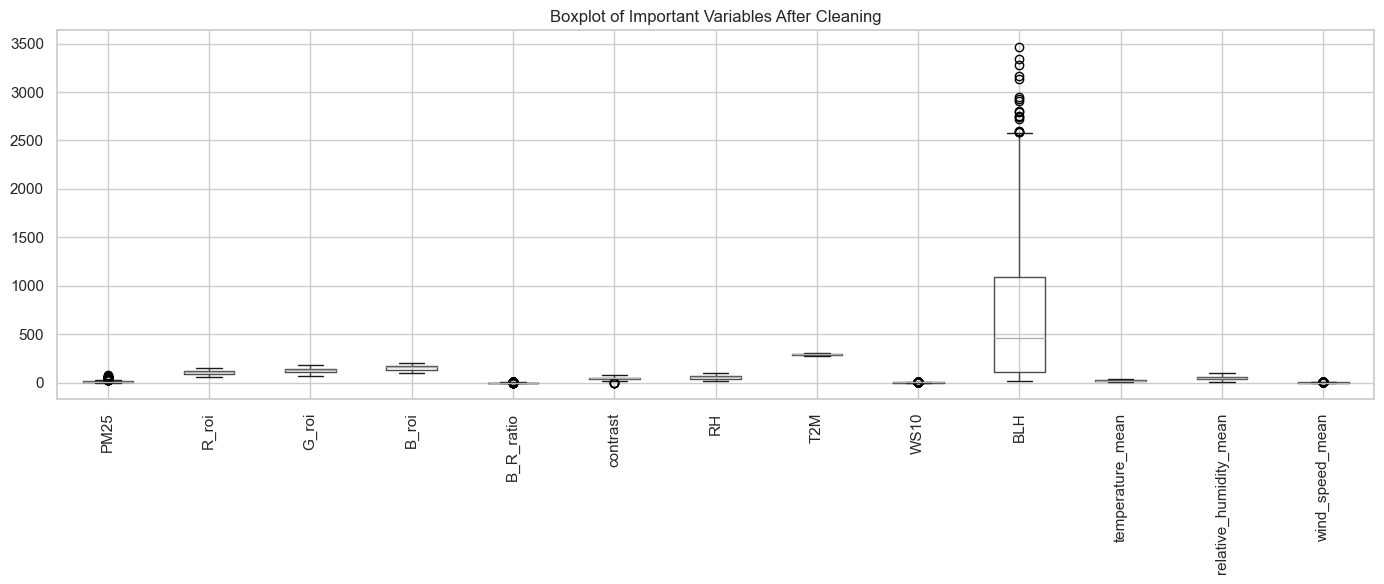

In [103]:
important_columns = [
    "PM25", "R_roi","G_roi","B_roi","B_R_ratio","contrast","RH","T2M","WS10",
    "BLH", "temperature_mean","relative_humidity_mean","wind_speed_mean",]

plot_columns = [
    col for col in important_columns
    if col in df.columns]

plt.figure(figsize=(14, 6))

df[plot_columns].boxplot(rot=90)

plt.title("Boxplot of Important Variables After Cleaning")

plt.tight_layout()

plt.show()

### 5.3 Correlation with PM2.5

Inspect the relationship between PM2.5 and selected environmental variables.

In [104]:
corr_with_pm25 = (
    df
    .select_dtypes(include=np.number)
    .corr()["PM25"]
    .sort_values(ascending=False)
)

print("Top positive correlations with PM2.5:")
display(corr_with_pm25.head(10))

print("\nTop negative correlations with PM2.5:")
display(corr_with_pm25.tail(10))

Top positive correlations with PM2.5:


PM25                      1.000000
SP                        0.432975
relative_humidity_mean    0.373334
RH                        0.313234
V_850                     0.198240
GP_850                    0.185730
V_500                     0.177343
hour_sin                  0.121512
V10                       0.104095
R_roi                     0.100854
Name: PM25, dtype: float64


Top negative correlations with PM2.5:


T_500              -0.204485
CBH                -0.222857
wind_speed_mean    -0.226138
S_mean             -0.234383
contrast           -0.266084
WS10               -0.268785
T2M                -0.271197
T_850              -0.274323
temperature_mean   -0.283162
month              -0.406452
Name: PM25, dtype: float64

### 5.4 PM2.5 Time Series

Visualize the temporal variation of PM2.5 concentrations.

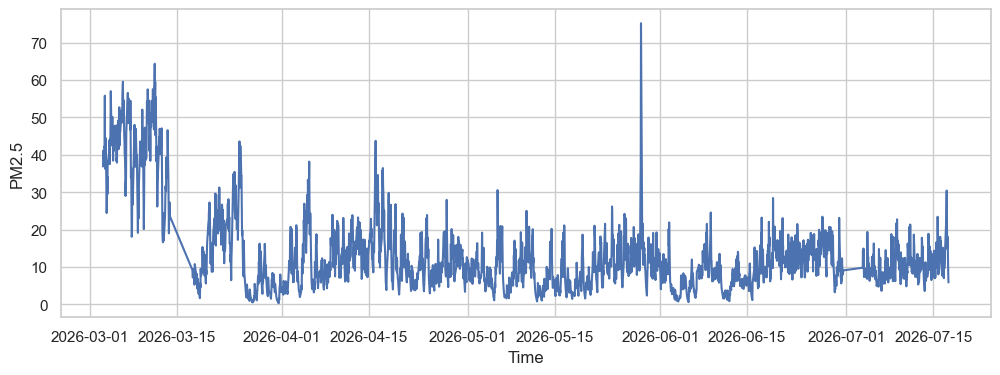

In [105]:
plt.figure(figsize=(12, 4))

plt.plot(
    df["time"],
    df["PM25"]
)

plt.xlabel("Time")
plt.ylabel("PM2.5")

plt.show()

## 6. Export & Summary

### 6.1 Export Cleaned Dataset

Export the final cleaned dataset for subsequent modeling and analysis.

In [106]:
OUTPUT_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "final_dataset.csv"
)

OUTPUT_FILE.parent.mkdir(
    parents=True,
    exist_ok=True
)

df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("Final dataset exported to:")
print(
    OUTPUT_FILE.relative_to(PROJECT_ROOT)
)

Final dataset exported to:
data/processed/final_dataset.csv


### 6.2 Final Summary

Summarize the final structure and quality of the cleaned dataset.

In [107]:
print("Final dataset summary")

print("\nRows:", len(df))
print("Columns:", df.shape[1])

print("\nRemaining missing values:",df.isna().sum().sum())

print("\nTime range:",df["time"].min(), "to",df["time"].max())

Final dataset summary

Rows: 2581
Columns: 40

Remaining missing values: 0

Time range: 2026-03-03 03:00:00 to 2026-07-17 11:00:00
